In [3]:
%load_ext autoreload
%autoreload 2

from src.dynamical_systems import *
from src.helpers import *
from src.experiments import *

import matplotlib.pyplot as plt

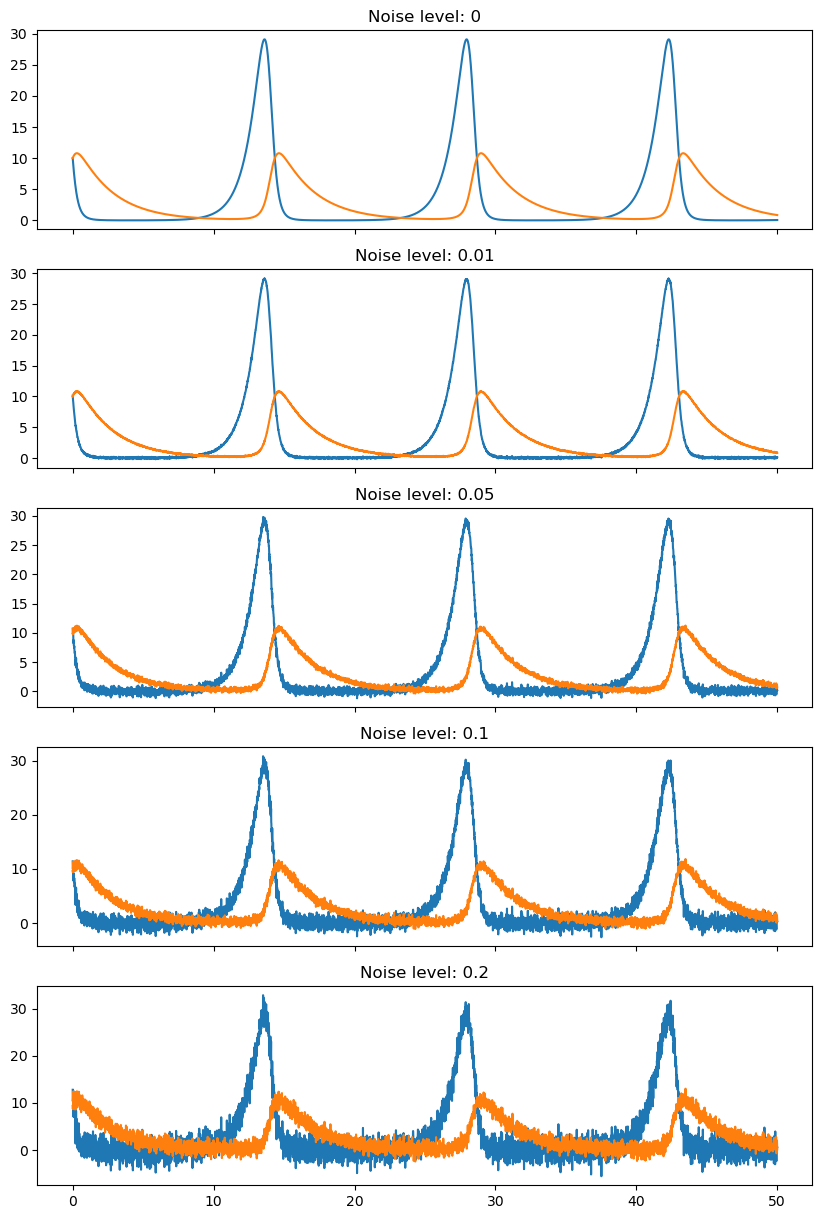

In [9]:
rhs = generate_lotka_volterra_rhs(*default_params['lotka_volterra'])
x0 = default_x0['lotka_volterra']
t_span = (0, 50)

dt = 0.01

t_eval = np.arange(t_span[0], t_span[1] + dt, dt)

x_train = generate_training_data(rhs, x0, t_eval)

noise_levels = [0, 0.01, 0.05, 0.1, 0.2]

fig, axs = plt.subplots(len(noise_levels), 1, figsize=(10, 3*len(noise_levels)), sharex=True)

for i in range(len(noise_levels)):
    noise_level = noise_levels[i]
    x_train_noisy = add_noise_to_data(x_train, noise_level)

    axs[i].plot(t_eval, x_train_noisy.T)
    axs[i].set_title(f"Noise level: {noise_level}")

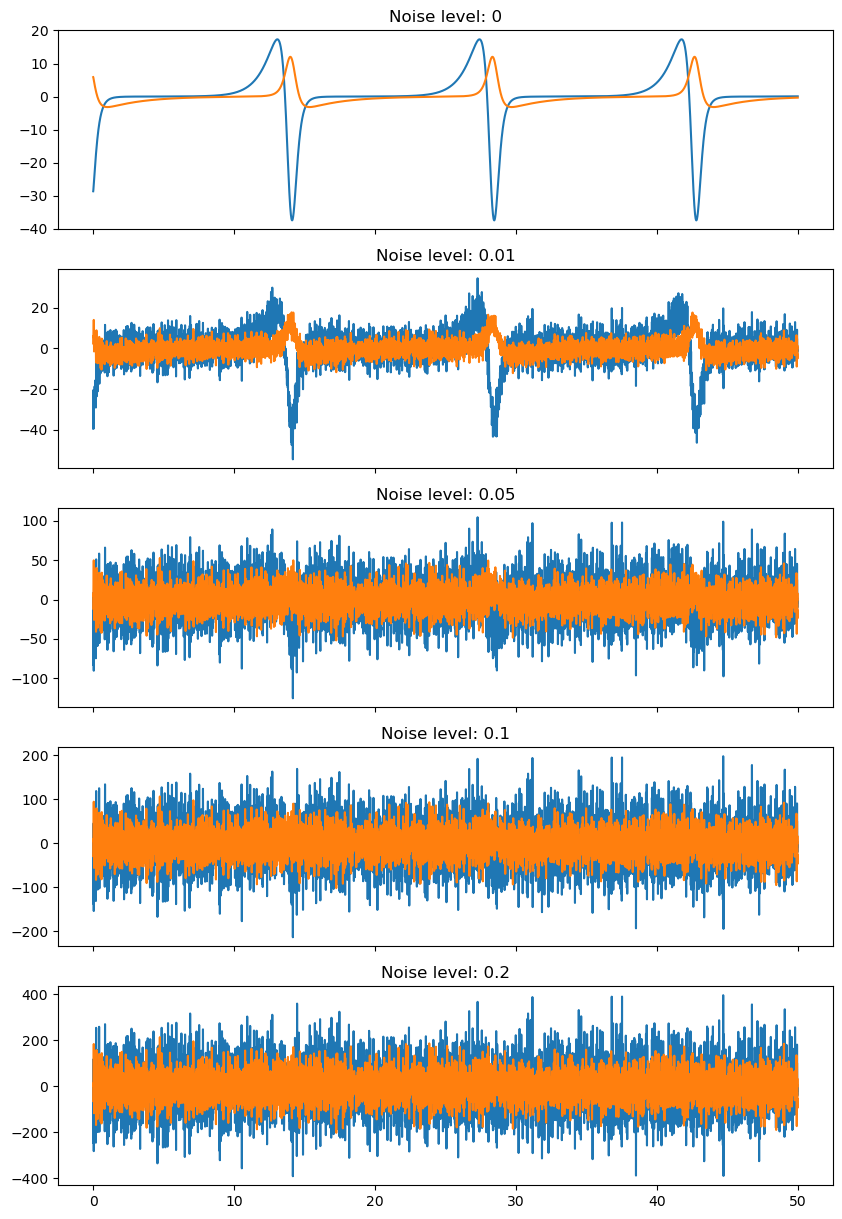

In [11]:
fig, axs = plt.subplots(len(noise_levels), 1, figsize=(10, 3*len(noise_levels)), sharex=True)

for i in range(len(noise_levels)):
    noise_level = noise_levels[i]
    x_train_noisy = add_noise_to_data(x_train, noise_level)

    x_dot_train_noisy = dxdt_finite_difference(x_train_noisy, t_eval)

    axs[i].plot(t_eval, x_dot_train_noisy.T)
    axs[i].set_title(f"Noise level: {noise_level}")

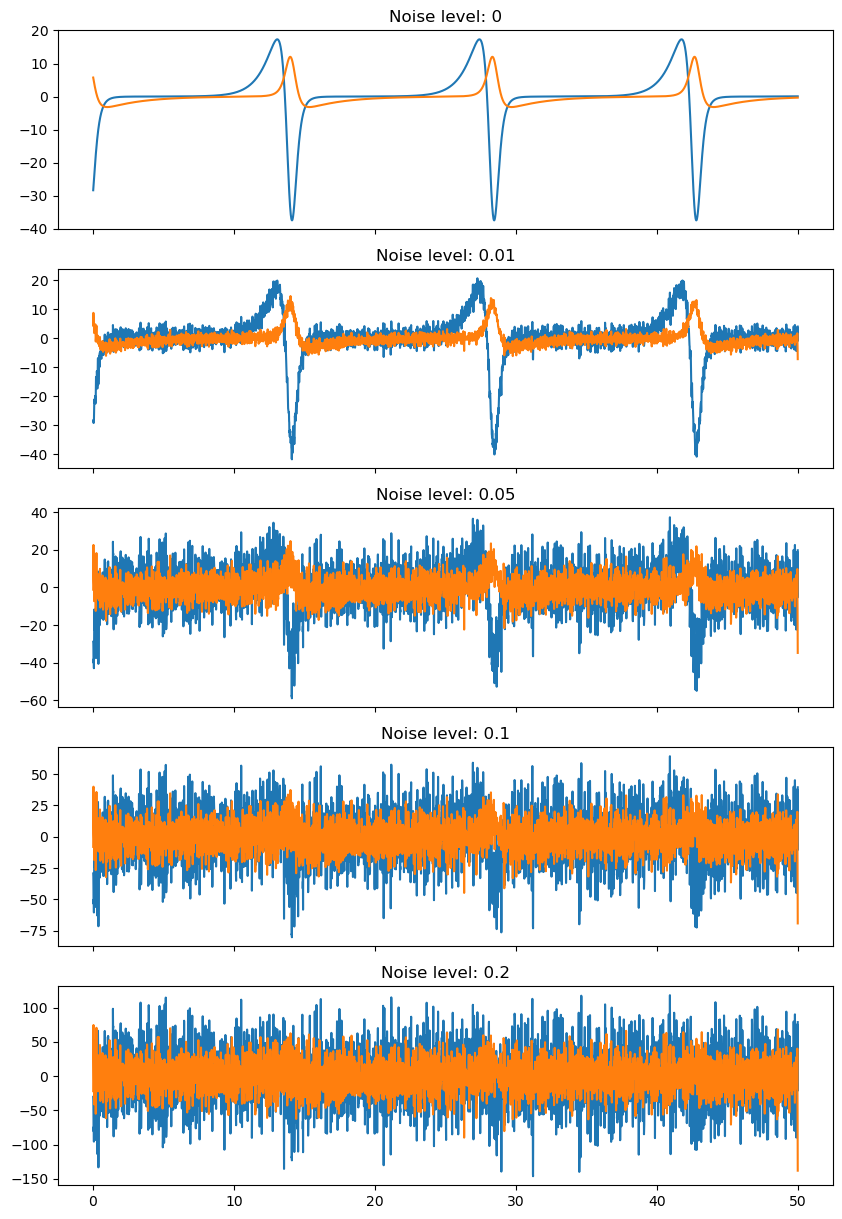

In [13]:
fig, axs = plt.subplots(len(noise_levels), 1, figsize=(10, 3*len(noise_levels)), sharex=True)

for i in range(len(noise_levels)):
    noise_level = noise_levels[i]
    x_train_noisy = add_noise_to_data(x_train, noise_level)

    x_dot_train_noisy = dxdt_poly_fit(x_train_noisy, t_eval, poly_deg=3, window_diameter=5)

    axs[i].plot(t_eval[1:], x_dot_train_noisy.T[1:])
    axs[i].set_title(f"Noise level: {noise_level}")